
Bad key axes.grid.alpha in file /Users/krzywdaja/Documents/noisy-learning-advantage/figures_notebooks/single_column.mplstyle, line 30 ('axes.grid.alpha   : 0.35')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.9.4/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


/var/folders/wj/x78z9z710q7csr068fhd10bxk7mx3x/T/ipykernel_71569/909539930.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


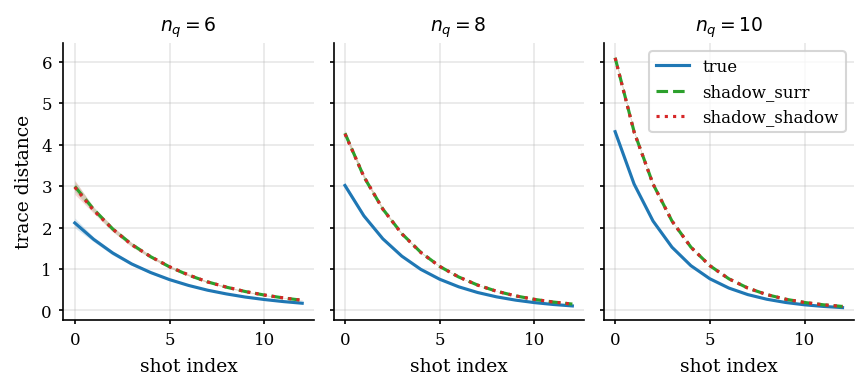

Valid channels used per n and case:
n=6: {'true': [0, 1, 2, 3], 'shadow_surr': [4, 5], 'shadow_shadow': [6]}
n=8: {'true': [0, 1, 2, 3], 'shadow_surr': [4], 'shadow_shadow': [6]}
n=10: {'true': [0, 2, 3], 'shadow_surr': [4, 5], 'shadow_shadow': [6]}


In [10]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Match style used in figures_notebooks/fig4_nps_nq_alpha_ch.ipynb
REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / '.git').exists():
    REPO_ROOT = REPO_ROOT.parent
plt.style.use(str(REPO_ROOT / 'figures_notebooks' / 'single_column.mplstyle'))


def load_distances_for_n(nq):
    candidates = [
        REPO_ROOT / 'paper_data' / 'shadow_surrogate_comparison' / f'distances_{nq}.npy',
        REPO_ROOT / 'surogate' / f'distances_{nq}.npy',
    ]
    for p in candidates:
        if p.exists():
            return np.load(p)
    raise FileNotFoundError(f'Could not find distances_{nq}.npy in known locations.')


def channel_is_valid(arr, idx):
    # Some channels are unfilled in saved arrays; skip all-zero channels.
    return not np.all(arr[idx] == 0)


def reconstruct_case_mu_std(arr, case_to_indices):
    shots_len = arr.shape[3]
    out = {}

    for case, idxs in case_to_indices.items():
        valid_idxs = [i for i in idxs if channel_is_valid(arr, i)]
        mu = np.full(shots_len, np.nan)
        std = np.full(shots_len, np.nan)

        for i_k in range(shots_len):
            if valid_idxs:
                vals = np.concatenate([arr[i, :, :, i_k, :, :].ravel() for i in valid_idxs])
                mu[i_k] = np.mean(vals)
                std[i_k] = np.std(vals)

        out[case] = {'mu': mu, 'std': std, 'valid_channels': valid_idxs}

    return out


CASE_TO_INDICES = {
    'true': [0, 1, 2, 3],
    'shadow_surr': [4, 5],
    'shadow_shadow': [6],
}

arrays = {nq: load_distances_for_n(nq) for nq in [6, 8, 10]}
stats_by_n = {nq: reconstruct_case_mu_std(arrays[nq], CASE_TO_INDICES) for nq in [6, 8, 10]}

fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.4), sharey=True, gridspec_kw={'wspace': 0.08})

case_style = {
    'true': ('-', '#1f77b4', 'true'),
    'shadow_surr': ('--', '#2ca02c', 'shadow_surr'),
    'shadow_shadow': (':', '#d62728', 'shadow_shadow'),
}

for ax, nq in zip(axes, [6, 8, 10]):
    x = np.arange(stats_by_n[nq]['true']['mu'].shape[0])
    for case, (ls, color, label) in case_style.items():
        mu = stats_by_n[nq][case]['mu']
        std = stats_by_n[nq][case]['std']
        ax.plot(x, mu, ls=ls, color=color, lw=1.5)
        ax.fill_between(x, mu - std, mu + std, color=color, alpha=0.18, linewidth=0)

    ax.set_title(rf'$n_q={nq}$')
    ax.set_xlabel('shot index')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('trace distance')

legend_handles = [
    mlines.Line2D([0], [0], color=c, ls=ls, lw=1.5, label=lab)
    for _, (ls, c, lab) in case_style.items()
]
axes[-1].legend(handles=legend_handles, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

print('Valid channels used per n and case:')
for nq in [6, 8, 10]:
    print(f'n={nq}:', {k: v['valid_channels'] for k, v in stats_by_n[nq].items()})


n=6: mean(true_surr_1 - true_shadow_1)=+0.001406, max_abs_diff=0.029590
n=8: mean(true_surr_1 - true_shadow_1)=-0.001508, max_abs_diff=0.021601
n=10: mean(true_surr_1 - true_shadow_1)=+0.001020, max_abs_diff=0.006291


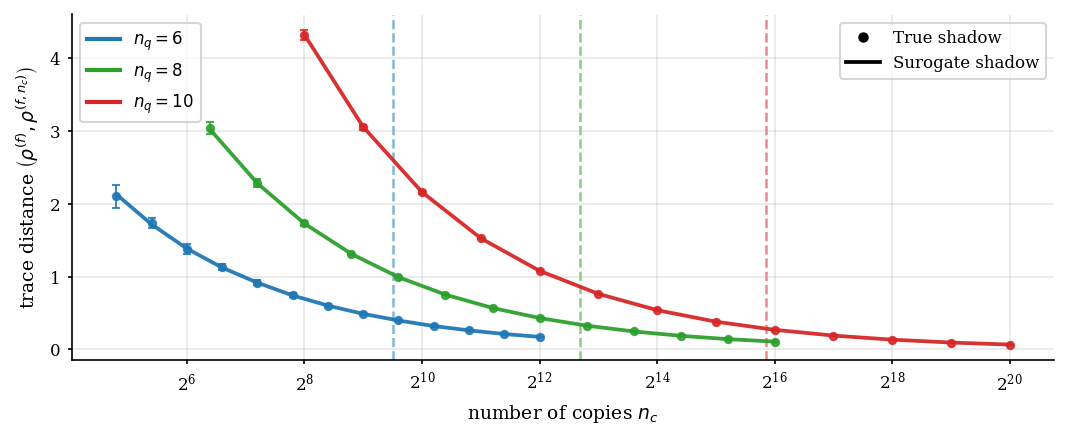

In [17]:
# Focused comparison in one panel:
# true_shadow_1 (idx 0) as points+error bars vs true_surr_1 (idx 2) as lines

from matplotlib.lines import Line2D


def mu_std_for_single_index(arr, idx):
    shots_len = arr.shape[3]
    mu = np.zeros(shots_len)
    std = np.zeros(shots_len)
    for i_k in range(shots_len):
        vals = arr[idx, :, :, i_k, :, :].ravel()
        mu[i_k] = np.mean(vals)
        std[i_k] = np.std(vals)
    return mu, std


fig, ax = plt.subplots(1, 1, figsize=(7.2, 3.0))

colors = {6: '#1f77b4', 8: '#2ca02c', 10: '#d62728'}
nq_handles = []

# Same convention as in fig4 notebook:
# k = log2(n_ps) / n_q  ->  n_ps = 2^(k*n_q)
k_target_full = np.array([0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.1])

for nq in [6, 8, 10]:
    arr = arrays[nq]
    mu_ts1, std_ts1 = mu_std_for_single_index(arr, 0)  # true_shadow_1
    mu_tu1, std_tu1 = mu_std_for_single_index(arr, 2)  # true_surr_1

    n_pts = mu_ts1.shape[0]
    k_exp = k_target_full[:n_pts]
    nps = 2.0 ** (k_exp * nq)

    # true shadow: points + error bars
    ax.errorbar(
        nps,
        mu_ts1,
        yerr=std_ts1,
        fmt='o',
        ms=3.5,
        lw=1.0,
        capsize=2.0,
        color=colors[nq],
        alpha=0.85,
        zorder=3,
    )

    # surrogate: line
    ax.plot(
        nps,
        mu_tu1,
        color=colors[nq],
        lw=1.8,
        ls='-',
        alpha=0.95,
        zorder=2,
    )

    # n_ps = 3^(n_q) now appears at different x for each n_q
    ax.axvline(
        x=3.0 ** nq,
        color=colors[nq],
        lw=1.2,
        ls='--',
        alpha=0.55,
        zorder=1,
    )

    nq_handles.append(Line2D([0], [0], color=colors[nq], lw=2.0, label=rf'$n_q={nq}$'))

    delta = mu_tu1 - mu_ts1
    print(
        f'n={nq}: mean(true_surr_1 - true_shadow_1)={np.mean(delta):+.6f}, '
        f'max_abs_diff={np.max(np.abs(delta)):.6f}'
    )

method_handles = [
    Line2D([0], [0], marker='o', color='k', lw=0, markersize=4, label='True shadow'),
    Line2D([0], [0], color='k', lw=1.8, ls='-', label='Surogate shadow'),
]

ax.set_xscale('log', base=2)
ax.set_xlabel('number of copies $n_c$')
ax.set_ylabel(r'trace distance $\left(\rho^{(f)}, \rho^{(f,n_c)}\right)$')
ax.grid(True, alpha=0.3, which='both')

legend_nq = ax.legend(handles=nq_handles, loc='upper left', fontsize=8)
ax.add_artist(legend_nq)
ax.legend(handles=method_handles, loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig("appe_surr_shadow_tr.pdf")